# Experimental Feature Selection into XGBoost training

This work managed scores vs ideal strong case
| Metric | Now | Bad / weak | Usable | Good | Strong | Excellent |
|---|---:|---:|---:|---:|---:|---:|
| **ROC-AUC** | ~0.69–0.70 | < 0.65 | 0.65-0.72 | 0.72-0.80 | 0.80-0.87 | > 0.87 |
| **PR-AUC** | ~0.41–0.43 | < 0.32 | 0.32-0.40 | 0.40-0.50 | 0.50-0.65 | > 0.65 |
| **Precision (positive class)** | ~0.38 | < 0.35 | 0.35-0.45 | 0.45-0.55 | 0.55-0.65 | > 0.65 |
| **Recall (positive class)** | ~0.64 | < 0.35 | 0.35-0.50 | 0.50-0.65 | 0.65-0.80 | > 0.80 |
| **F1-score (positive class)** | ~0.48 | < 0.35 | 0.35-0.45 | 0.45-0.55 | 0.55-0.65 | > 0.65 |

Idea to test in the future to try to balance the dataset. The XGBoost is balancing the dataset by itself\
(scale_pos_weight=(y_train == 0).sum() / max((y_train == 1).sum(), 1))\
But it could add some value

next step on what to focus more again:
1. feature engineering
2. feature selection / noise reduction
3. threshold tuning
4. hyperparameter tuning
5. imbalance experiments if still needed

## Load data

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("../../data/processed/sample.csv", sep="|")
# df = pd.read_csv("../../data/processed/processed_joined_dataset.csv", sep="|")
df.head()

,lineID,day,pid,adFlag,availability,competitorPrice,click,basket,order,price,...,rrp,has_competitor,campaignIndex_A,campaignIndex_B,campaignIndex_C,price_diff_competitor,price_ratio_competitor,price_pct_diff_competitor,is_post_shift_day,price_diff_vs_previous_available_day
0,978899,39,9624,0,1,17.19,1,0,0,19.89,...,21.51,1,0,0,0,2.70,1.1571,15.71,1,0.0
1,1267035,47,3969,1,1,18.13,1,0,0,20.85,...,26.07,1,0,0,0,2.72,1.1500,15.00,1,0.0
2,297914,14,16633,0,1,15.06,0,0,1,16.45,...,23.98,1,0,1,0,1.39,1.0923,9.23,0,0.0
3,2554963,87,20147,0,1,4.36,1,0,0,5.17,...,5.45,1,0,0,0,0.81,1.1858,18.58,1,0.0
4,2739211,92,14326,0,1,NaN,0,0,1,6.22,...,6.55,0,0,0,0,NaN,NaN,NaN,1,0.0


In [3]:
print(df.shape)
print(df.columns.tolist())

(200000, 29)
['lineID', 'day', 'pid', 'adFlag', 'availability', 'competitorPrice', 'click', 'basket', 'order', 'price', 'revenue', 'manufacturer', 'group', 'content', 'unit', 'pharmForm', 'genericProduct', 'salesIndex', 'category', 'rrp', 'has_competitor', 'campaignIndex_A', 'campaignIndex_B', 'campaignIndex_C', 'price_diff_competitor', 'price_ratio_competitor', 'price_pct_diff_competitor', 'is_post_shift_day', 'price_diff_vs_previous_available_day']


In [4]:
df.isna().sum().sort_values(ascending=False)


competitorPrice                         7195
price_pct_diff_competitor               7195
price_diff_competitor                   7195
price_ratio_competitor                  7195
category                                6290
price_diff_vs_previous_available_day    2653
availability                               0
basket                                     0
click                                      0
day                                        0
pid                                        0
adFlag                                     0
lineID                                     0
group                                      0
manufacturer                               0
revenue                                    0
price                                      0
order                                      0
content                                    0
pharmForm                                  0
unit                                       0
has_competitor                             0
rrp       

## Target definition and removing obvious leakage

In [5]:
target = "order"

drop_cols = [
    "order",      # target
    "click",      # leakage
    "basket",     # leakage
    "revenue",    # leakage
    "lineID",     # identifier
    "pid",        # identifier / memorization risk
    "unit"        # useless (for now)
]

## Perform Feature Selection

- remove obvious bad columns manually
- separate numeric and categorical
- mutual_info_classif for a first relevance ranking

In [6]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif, SelectKBest

target = "order"

drop_cols = [
    "order",
    "click",
    "basket",
    "revenue",
    "lineID",
    "pid",
    "unit",
    "competitorPrice", "rrp", "price_ratio_competitor" #idea from correlation analysis. Improves current results by 2%
]

extra_drop = ["group", "pharmForm"]

# 1. Build numeric feature matrix
X_num = (
    df.drop(columns=drop_cols + extra_drop, errors="ignore")
      .select_dtypes(include=["number"])
      .copy()
)

y = df[target].copy()

# 2. Clean inf values
X_num = X_num.replace([np.inf, -np.inf], np.nan)

# 3. Temporary fill only for sklearn selector
X_num_filled = X_num.fillna(X_num.median())

# 4. Run selector / ranking
selector = SelectKBest(score_func=mutual_info_classif, k="all")
selector.fit(X_num_filled, y)

# 5. Put results into table
mi_df = pd.DataFrame({
    "feature": X_num_filled.columns,
    "score": selector.scores_
}).sort_values("score", ascending=False)

# mi_df

In [7]:
mi_df

,feature,score
13,is_post_shift_day,0.035144
12,price_pct_diff_competitor,0.030477
7,has_competitor,0.029207
2,availability,0.027694
6,salesIndex,0.019291
3,price,0.019045
11,price_diff_competitor,0.012451
0,day,0.010270
1,adFlag,0.009843
4,content,0.006886


### Plot

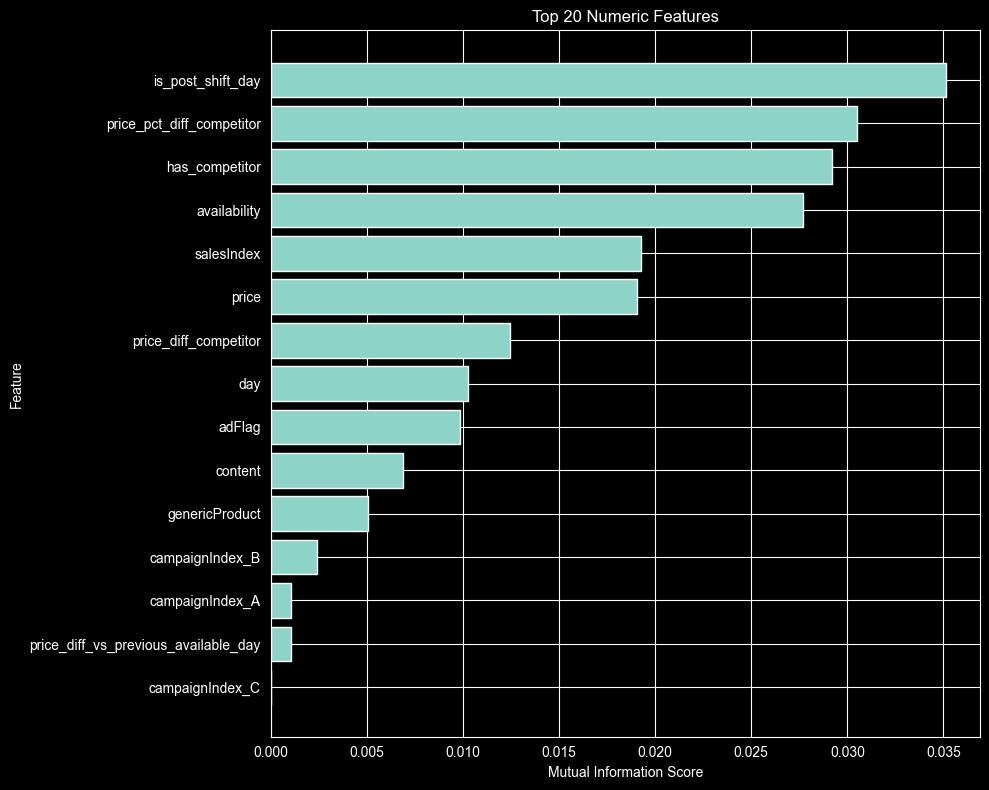

In [8]:
import matplotlib.pyplot as plt

plot_df = mi_df.head(20).sort_values("score")

plt.figure(figsize=(10, 8))
plt.barh(plot_df["feature"], plot_df["score"])
plt.xlabel("Mutual Information Score")
plt.ylabel("Feature")
plt.title("Top 20 Numeric Features")
plt.tight_layout()
plt.show()

## Bivariate selection

### Prepare numeric features for correlation analysis

In [9]:
# Build feature matrix and target
X = df.drop(columns=drop_cols, errors="ignore").copy()
y = df[target].copy()

# Keep only numeric features for correlation analysis
X_num = X.select_dtypes(include=["number"]).copy()

print(X_num.shape)
print(X_num.columns.tolist())

# Replace infinite values with NaN
X_num = X_num.replace([np.inf, -np.inf], np.nan)

# Fill missing numeric values temporarily for correlation analysis
X_num_filled = X_num.fillna(X_num.median())

print("Remaining missing values:", X_num_filled.isna().sum().sum())

(200000, 15)
['day', 'adFlag', 'availability', 'price', 'content', 'genericProduct', 'salesIndex', 'has_competitor', 'campaignIndex_A', 'campaignIndex_B', 'campaignIndex_C', 'price_diff_competitor', 'price_pct_diff_competitor', 'is_post_shift_day', 'price_diff_vs_previous_available_day']
Remaining missing values: 0


### Compute Pearson correlation matrix

                                           day    adFlag  availability  \
day                                   1.000000 -0.023937      0.016288   
adFlag                               -0.023937  1.000000     -0.172356   
availability                          0.016288 -0.172356      1.000000   
price                                 0.023820  0.025675      0.048427   
content                               0.015524 -0.069700     -0.015164   
genericProduct                       -0.021847  0.122598     -0.056702   
salesIndex                            0.010320 -0.296374      0.054251   
has_competitor                        0.001397  0.085954     -0.069141   
campaignIndex_A                      -0.064406  0.096246     -0.036378   
campaignIndex_B                       0.010752  0.174766     -0.075431   
campaignIndex_C                      -0.017549 -0.008310     -0.021796   
price_diff_competitor                -0.001145  0.079124      0.021361   
price_pct_diff_competitor            -

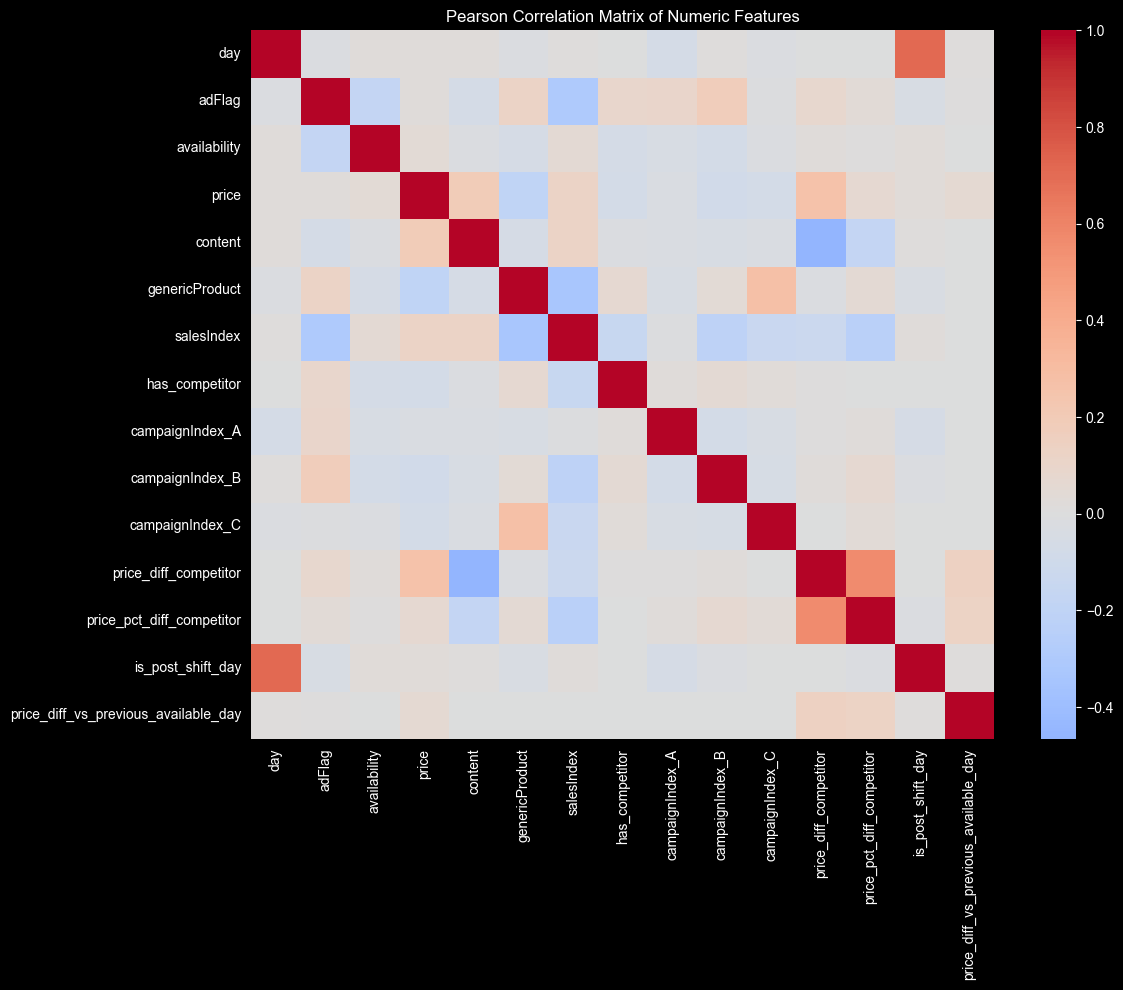

In [10]:
corr_matrix = X_num_filled.corr(method="pearson")
print(corr_matrix)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Pearson Correlation Matrix of Numeric Features")
plt.tight_layout()
plt.show()

### Extract highly correlated feature pairs

In [11]:
corr_abs = corr_matrix.abs()

upper_triangle = corr_abs.where(
    np.triu(np.ones(corr_abs.shape), k=1).astype(bool)
)

threshold = 0.8
high_corr_pairs = []

for col in upper_triangle.columns:
    for row in upper_triangle.index:
        corr_value = upper_triangle.loc[row, col]
        if pd.notna(corr_value) and corr_value > threshold:
            high_corr_pairs.append((row, col, corr_value))

high_corr_df = pd.DataFrame(
    high_corr_pairs,
    columns=["feature_1", "feature_2", "correlation"]
).sort_values("correlation", ascending=False)

high_corr_df

,feature_1,feature_2,correlation


These features are strongly correlated and might be redundant to use them all

## Split data
The top 10 numeric features were selected based on their mutual information ranking. These features were used to create the final input matrix X, which was then split into training and test sets using a stratified split. Stratification ensures that the proportion of purchased and non-purchased items remains similar in both subsets, making the evaluation more reliable.

In [13]:
from sklearn.model_selection import train_test_split

top_10_features = mi_df.head(10)["feature"].tolist()
X = X_num_filled[top_10_features].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)
print(X_train.columns)
print(y_train.mean(), y_test.mean())

(160000, 10) (40000, 10)
Index(['is_post_shift_day', 'price_pct_diff_competitor', 'has_competitor',
       'availability', 'salesIndex', 'price', 'price_diff_competitor', 'day',
       'adFlag', 'content'],
      dtype='str')
0.25585625 0.25585


### check if we have missing values
if 0 missing values we can proceed otherwise we need to fix it

In [ ]:
print("Missing values in X_train before imputation:")
print(X_train.isna().sum().sort_values(ascending=False))

print("\nMissing values in X_test before imputation:")
print(X_test.isna().sum().sort_values(ascending=False))

## Training XGBoost
An XGBoost classifier was trained on the selected numeric features to predict whether a product would be purchased (order = 1). The model was configured with a set of initial hyperparameters and adjusted for class imbalance using scale_pos_weight, so that the minority class received more attention during training. After fitting the model on the training data, predictions and predicted probabilities were generated for the test set, and the model performance was evaluated using ROC-AUC, PR-AUC, the classification report, and the confusion matrix.

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, confusion_matrix

model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss",
    scale_pos_weight=(y_train == 0).sum() / max((y_train == 1).sum(), 1)
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))
print("PR-AUC:", average_precision_score(y_test, y_pred_proba))
print("\nClassification report:")
print(classification_report(y_test, y_pred))
print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))

## Interpretation of XGBoost Results
The XGBoost model achieved a ROC-AUC of 0.679 and a PR-AUC of 0.401, indicating that it performs better than random guessing and is able to capture meaningful patterns related to purchase behavior. However, the performance is still moderate, which suggests that the selected numeric features alone are not sufficient for highly accurate prediction.

The classification report shows that the model performs noticeably better on the majority class (order = 0) than on the minority class (order = 1). For the purchase class, the model reached a precision of 0.37 and a recall of 0.62. This means that it was able to identify a relatively large share of actual purchases, but many of the predicted purchases were false positives.

This pattern is also visible in the confusion matrix. The model correctly identified 6,390 true purchases, but at the same time incorrectly predicted 10,896 non-purchases as purchases. In practical terms, the model is relatively sensitive to purchase cases, but its positive predictions are not very precise.

Overall, the model provides a reasonable first baseline and confirms that there is predictive signal in the dataset. At the same time, the results indicate that further improvement is needed, for example through additional feature engineering, better handling of categorical variables, or model tuning.

## Try again but with all features (top10, top15, all)

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, precision_score, recall_score, f1_score
import pandas as pd

feature_sets = {
    "top_10": mi_df.head(10)["feature"].tolist(),
    "top_15": mi_df.head(15)["feature"].tolist(),
    "all_numeric": mi_df["feature"].tolist()
}

results = []

for name, features in feature_sets.items():
    X_current = X_num_filled[features].copy()

    X_train, X_test, y_train, y_test = train_test_split(
        X_current,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    model = XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss",
        scale_pos_weight=(y_train == 0).sum() / max((y_train == 1).sum(), 1)
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    results.append({
        "feature_set": name,
        "n_features": len(features),
        "roc_auc": roc_auc_score(y_test, y_pred_proba),
        "pr_auc": average_precision_score(y_test, y_pred_proba),
        "precision_1": precision_score(y_test, y_pred),
        "recall_1": recall_score(y_test, y_pred),
        "f1_1": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results).sort_values("pr_auc", ascending=False)
results_df

## Interpretation of Feature Set Comparison

The comparison of different feature subset sizes showed that the top 15 ranked numeric features produced the best overall performance. Compared with the top 10 feature model, the inclusion of additional variables improved ROC-AUC, PR-AUC, recall, and F1-score, indicating that the top 10 subset was too restrictive. Expanding further to all available numeric features did not lead to additional improvement, which suggests that the strongest predictive information was already captured within the top 15 features.

# New approach

These sections extend the notebook without changing the original experiments above.
Each approach keeps the same business goal but tests a stronger modeling or analytical angle.


## Shared helper functions for the new experiments
- keep the original XGBoost setup comparable
- compare every new experiment with the two strongest baselines already present in this notebook
- avoid overwriting the original variables as much as possible


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from xgboost import XGBClassifier

BASELINE_TOP10 = {
    "experiment": "baseline_top_10",
    "roc_auc": 0.6944893477048804,
    "pr_auc": 0.4146288608676567,
    "precision_1": 0.382166,
    "recall_1": 0.635626,
    "f1_1": 0.477337
}

BASELINE_ALL_NUMERIC = {
    "experiment": "baseline_all_numeric",
    "roc_auc": 0.704999,
    "pr_auc": 0.428479,
    "precision_1": 0.385762,
    "recall_1": 0.653793,
    "f1_1": 0.485224
}

def build_xgb(scale_pos_weight=1.0):
    return XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight
    )

def clean_train_test_numeric(X_train, X_test):
    X_train = X_train.replace([np.inf, -np.inf], np.nan).copy()
    X_test = X_test.replace([np.inf, -np.inf], np.nan).copy()

    train_medians = X_train.median(numeric_only=True)
    X_train = X_train.fillna(train_medians)
    X_test = X_test.fillna(train_medians)

    return X_train, X_test

def evaluate_binary_model(model, X_eval, y_eval, threshold=0.5):
    y_proba = model.predict_proba(X_eval)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)

    metrics = {
        "roc_auc": roc_auc_score(y_eval, y_proba),
        "pr_auc": average_precision_score(y_eval, y_proba),
        "precision_1": precision_score(y_eval, y_pred, zero_division=0),
        "recall_1": recall_score(y_eval, y_pred, zero_division=0),
        "f1_1": f1_score(y_eval, y_pred, zero_division=0),
    }

    return metrics, y_pred, y_proba

def compare_against_baselines(experiment_name, metrics_dict):
    rows = []

    for baseline in [BASELINE_TOP10, BASELINE_ALL_NUMERIC]:
        rows.append({
            "experiment": experiment_name,
            "compared_to": baseline["experiment"],
            "roc_auc": metrics_dict["roc_auc"],
            "pr_auc": metrics_dict["pr_auc"],
            "precision_1": metrics_dict["precision_1"],
            "recall_1": metrics_dict["recall_1"],
            "f1_1": metrics_dict["f1_1"],
            "delta_roc_auc": metrics_dict["roc_auc"] - baseline["roc_auc"],
            "delta_pr_auc": metrics_dict["pr_auc"] - baseline["pr_auc"],
            "delta_precision_1": metrics_dict["precision_1"] - baseline["precision_1"],
            "delta_recall_1": metrics_dict["recall_1"] - baseline["recall_1"],
            "delta_f1_1": metrics_dict["f1_1"] - baseline["f1_1"],
        })

    return pd.DataFrame(rows)

def get_top_feature_importance(model, columns, top_n=15):
    return (
        pd.Series(model.feature_importances_, index=columns)
        .sort_values(ascending=False)
        .head(top_n)
        .to_frame("importance")
    )

def add_price_position_features(df_in):
    df_out = df_in.copy()

    content_safe = df_out["content"].replace(0, np.nan)
    rrp_safe = df_out["rrp"].replace(0, np.nan)
    comp_safe = df_out["competitorPrice"].replace(0, np.nan)

    df_out["price_to_rrp_ratio"] = df_out["price"] / rrp_safe
    df_out["discount_to_rrp_pct"] = (df_out["rrp"] - df_out["price"]) / rrp_safe

    df_out["unit_price"] = df_out["price"] / content_safe
    df_out["unit_rrp"] = df_out["rrp"] / content_safe
    df_out["unit_competitor_price"] = df_out["competitorPrice"] / content_safe

    df_out["unit_price_to_rrp_ratio"] = df_out["unit_price"] / df_out["unit_rrp"]
    df_out["unit_price_to_comp_ratio"] = df_out["unit_price"] / df_out["unit_competitor_price"]

    df_out["is_cheaper_than_comp"] = (
        (df_out["competitorPrice"] > 0) &
        (df_out["price"] < df_out["competitorPrice"])
    ).astype(int)

    df_out["is_more_expensive_than_comp"] = (
        (df_out["competitorPrice"] > 0) &
        (df_out["price"] > df_out["competitorPrice"])
    ).astype(int)

    df_out["abs_price_pct_diff_competitor"] = df_out["price_pct_diff_competitor"].abs()
    df_out["week_index"] = ((df_out["day"] - 1) // 7).astype(int)

    return df_out

def add_history_features(df_in):
    df_hist = df_in.copy().sort_values(["pid", "day", "lineID"])

    pid_day = (
        df_hist.groupby(["pid", "day"], as_index=False)
        .agg(
            pid_day_interactions=("order", "size"),
            pid_day_orders=("order", "sum"),
            pid_day_price=("price", "mean"),
            pid_day_availability=("availability", "mean")
        )
        .sort_values(["pid", "day"])
    )

    g_pid = pid_day.groupby("pid", sort=False)

    pid_day["pid_prev_day_orders"] = g_pid["pid_day_orders"].shift(1)
    pid_day["pid_prev_day_interactions"] = g_pid["pid_day_interactions"].shift(1)
    pid_day["pid_prev_day_order_rate"] = (
        pid_day["pid_prev_day_orders"] / pid_day["pid_prev_day_interactions"]
    )

    pid_day["pid_prev_3d_orders"] = g_pid["pid_day_orders"].transform(
        lambda s: s.shift(1).rolling(3, min_periods=1).sum()
    )
    pid_day["pid_prev_3d_interactions"] = g_pid["pid_day_interactions"].transform(
        lambda s: s.shift(1).rolling(3, min_periods=1).sum()
    )
    pid_day["pid_prev_3d_order_rate"] = (
        pid_day["pid_prev_3d_orders"] / pid_day["pid_prev_3d_interactions"]
    )

    pid_day["pid_prev_7d_orders"] = g_pid["pid_day_orders"].transform(
        lambda s: s.shift(1).rolling(7, min_periods=1).sum()
    )
    pid_day["pid_prev_7d_interactions"] = g_pid["pid_day_interactions"].transform(
        lambda s: s.shift(1).rolling(7, min_periods=1).sum()
    )
    pid_day["pid_prev_7d_order_rate"] = (
        pid_day["pid_prev_7d_orders"] / pid_day["pid_prev_7d_interactions"]
    )

    pid_day["pid_prev_price"] = g_pid["pid_day_price"].shift(1)
    pid_day["pid_price_change_pct"] = (
        pid_day["pid_day_price"] - pid_day["pid_prev_price"]
    ) / pid_day["pid_prev_price"]

    category_day = (
        df_hist.groupby(["category", "day"], as_index=False)
        .agg(
            category_day_interactions=("order", "size"),
            category_day_orders=("order", "sum")
        )
        .sort_values(["category", "day"])
    )

    g_cat = category_day.groupby("category", sort=False)
    category_day["category_prev_7d_orders"] = g_cat["category_day_orders"].transform(
        lambda s: s.shift(1).rolling(7, min_periods=1).sum()
    )
    category_day["category_prev_7d_interactions"] = g_cat["category_day_interactions"].transform(
        lambda s: s.shift(1).rolling(7, min_periods=1).sum()
    )
    category_day["category_prev_7d_order_rate"] = (
        category_day["category_prev_7d_orders"] / category_day["category_prev_7d_interactions"]
    )

    keep_pid_cols = [
        "pid", "day",
        "pid_prev_day_order_rate",
        "pid_prev_3d_order_rate",
        "pid_prev_7d_order_rate",
        "pid_prev_7d_interactions",
        "pid_price_change_pct",
    ]

    keep_cat_cols = [
        "category", "day",
        "category_prev_7d_order_rate"
    ]

    df_hist = df_hist.merge(pid_day[keep_pid_cols], on=["pid", "day"], how="left")
    df_hist = df_hist.merge(category_day[keep_cat_cols], on=["category", "day"], how="left")

    df_hist["has_pid_history"] = df_hist["pid_prev_day_order_rate"].notna().astype(int)
    df_hist["has_category_history"] = df_hist["category_prev_7d_order_rate"].notna().astype(int)

    return df_hist

def prepare_numeric_matrix(df_in, target_col="order"):
    drop_cols = [
        "order",
        "click",
        "basket",
        "revenue",
        "lineID",
        "pid",
        "unit"
    ]

    X_num = (
        df_in.drop(columns=drop_cols, errors="ignore")
        .select_dtypes(include=["number"])
        .copy()
    )
    y_vec = df_in[target_col].copy()

    return X_num, y_vec

def train_test_random_split(df_in):
    X_num, y_vec = prepare_numeric_matrix(df_in)

    X_train, X_test, y_train, y_test = train_test_split(
        X_num,
        y_vec,
        test_size=0.2,
        random_state=42,
        stratify=y_vec
    )

    X_train, X_test = clean_train_test_numeric(X_train, X_test)

    return X_train, X_test, y_train, y_test

def train_valid_test_time_split(df_in):
    X_num, y_vec = prepare_numeric_matrix(df_in)

    unique_days = np.array(sorted(df_in["day"].unique()))
    train_end_idx = int(len(unique_days) * 0.70)
    valid_end_idx = int(len(unique_days) * 0.85)

    train_days = unique_days[:train_end_idx]
    valid_days = unique_days[train_end_idx:valid_end_idx]
    test_days = unique_days[valid_end_idx:]

    train_mask = df_in["day"].isin(train_days)
    valid_mask = df_in["day"].isin(valid_days)
    test_mask = df_in["day"].isin(test_days)

    X_train = X_num.loc[train_mask].copy()
    y_train = y_vec.loc[train_mask].copy()

    X_valid = X_num.loc[valid_mask].copy()
    y_valid = y_vec.loc[valid_mask].copy()

    X_test = X_num.loc[test_mask].copy()
    y_test = y_vec.loc[test_mask].copy()

    train_medians = X_train.replace([np.inf, -np.inf], np.nan).median(numeric_only=True)

    X_train = X_train.replace([np.inf, -np.inf], np.nan).fillna(train_medians)
    X_valid = X_valid.replace([np.inf, -np.inf], np.nan).fillna(train_medians)
    X_test = X_test.replace([np.inf, -np.inf], np.nan).fillna(train_medians)

    split_info = {
        "train_days": (train_days.min(), train_days.max()),
        "valid_days": (valid_days.min(), valid_days.max()),
        "test_days": (test_days.min(), test_days.max()),
        "n_train": len(X_train),
        "n_valid": len(X_valid),
        "n_test": len(X_test),
    }

    return X_train, X_valid, X_test, y_train, y_valid, y_test, split_info


## 1) Richer price-position and pack-economics features
- add price vs competitor, price vs RRP, and content-normalized price features
- keep the split logic comparable to the original notebook first, so the effect of feature engineering is easier to isolate


### step 1
Create a new feature block focused on relative price positioning, discount depth, and price per unit of content.


In [ ]:
df_price_ext = add_price_position_features(df)

new_price_cols = [
    "price_to_rrp_ratio",
    "discount_to_rrp_pct",
    "unit_price",
    "unit_rrp",
    "unit_competitor_price",
    "unit_price_to_rrp_ratio",
    "unit_price_to_comp_ratio",
    "is_cheaper_than_comp",
    "is_more_expensive_than_comp",
    "abs_price_pct_diff_competitor",
    "week_index",
]

df_price_ext[new_price_cols].describe().T


### step 2
Build a numeric matrix with the original numeric variables plus the new price-position features, then train the same XGBoost setup.


In [ ]:
X_train_price_ext, X_test_price_ext, y_train_price_ext, y_test_price_ext = train_test_random_split(df_price_ext)

spw_price_ext = (y_train_price_ext == 0).sum() / max((y_train_price_ext == 1).sum(), 1)

model_price_ext = build_xgb(scale_pos_weight=spw_price_ext)
model_price_ext.fit(X_train_price_ext, y_train_price_ext)

metrics_price_ext, y_pred_price_ext, y_proba_price_ext = evaluate_binary_model(
    model_price_ext,
    X_test_price_ext,
    y_test_price_ext
)

pd.DataFrame([{
    "experiment": "price_position_and_pack_features",
    "n_features": X_train_price_ext.shape[1],
    **metrics_price_ext
}])


### evaluation
Compare the new result against the original top-10 baseline and the stronger all-numeric baseline from above.


In [ ]:
comparison_price_ext = compare_against_baselines(
    "price_position_and_pack_features",
    metrics_price_ext
)

top_importance_price_ext = get_top_feature_importance(
    model_price_ext,
    X_train_price_ext.columns,
    top_n=15
)

# display(comparison_price_ext)
# display(top_importance_price_ext)
print(confusion_matrix(y_test_price_ext, y_pred_price_ext))
print(classification_report(y_test_price_ext, y_pred_price_ext, zero_division=0))


### what we found out
- If the deltas versus `baseline_all_numeric` are positive, then relative positioning and pack-size economics add signal beyond the raw numeric baseline.
- Check whether `price_to_rrp_ratio`, `discount_to_rrp_pct`, `unit_price`, or `unit_price_to_comp_ratio` appear among the most important features.
- If they do, it supports the business idea that the customer reacts more to price positioning than to absolute price alone.


## 2) Historical product behavior features
- add lagged conversion and activity features per product and per category
- this tests whether recent demand history improves purchase prediction more than static product attributes alone


### step 1
Create lagged historical features using only previous days, so the notebook stays leakage-safe.


In [ ]:
df_history_ext = add_history_features(add_price_position_features(df))

history_feature_preview = [
    "pid_prev_day_order_rate",
    "pid_prev_3d_order_rate",
    "pid_prev_7d_order_rate",
    "pid_prev_7d_interactions",
    "pid_price_change_pct",
    "category_prev_7d_order_rate",
    "has_pid_history",
    "has_category_history",
]

df_history_ext[history_feature_preview].describe(include="all").T


### step 2
Train the same XGBoost model on the expanded feature matrix that now includes product history and category history.


In [ ]:
X_train_history_ext, X_test_history_ext, y_train_history_ext, y_test_history_ext = train_test_random_split(df_history_ext)

spw_history_ext = (y_train_history_ext == 0).sum() / max((y_train_history_ext == 1).sum(), 1)

model_history_ext = build_xgb(scale_pos_weight=spw_history_ext)
model_history_ext.fit(X_train_history_ext, y_train_history_ext)

metrics_history_ext, y_pred_history_ext, y_proba_history_ext = evaluate_binary_model(
    model_history_ext,
    X_test_history_ext,
    y_test_history_ext
)

pd.DataFrame([{
    "experiment": "history_features",
    "n_features": X_train_history_ext.shape[1],
    **metrics_history_ext
}])


### evaluation
Check whether lagged product behavior lifts ROC-AUC and PR-AUC beyond the stronger all-numeric baseline.


In [ ]:
comparison_history_ext = compare_against_baselines(
    "history_features",
    metrics_history_ext
)

top_importance_history_ext = get_top_feature_importance(
    model_history_ext,
    X_train_history_ext.columns,
    top_n=20
)

# display(comparison_history_ext)
# display(top_importance_history_ext)
print(confusion_matrix(y_test_history_ext, y_pred_history_ext))
print(classification_report(y_test_history_ext, y_pred_history_ext, zero_division=0))


### what we found out
- If lagged conversion features move to the top of the importance ranking, then recent product performance contains information that the static feature set was missing.
- If PR-AUC improves in particular, the model is getting better at separating likely purchases from the large pool of non-purchases.
- This would support a business strategy where pricing decisions depend partly on recent demand momentum, not only on today’s price gap.


## 3) Time-based validation instead of a random split
- random splits are useful for quick experimentation, but this problem is time-dependent
- here the goal is to evaluate the model on future days only, which is closer to the real business setting


### step 1
Use the strongest engineered dataset so far and split it into train, validation, and test by day order.


In [ ]:
df_time_ext = add_history_features(add_price_position_features(df))

X_train_time_ext, X_valid_time_ext, X_test_time_ext, y_train_time_ext, y_valid_time_ext, y_test_time_ext, split_info_time_ext = train_valid_test_time_split(df_time_ext)

pd.DataFrame([split_info_time_ext])


### step 2
Train on the earlier period and evaluate separately on validation and test periods.


In [ ]:
spw_time_ext = (y_train_time_ext == 0).sum() / max((y_train_time_ext == 1).sum(), 1)

model_time_ext = build_xgb(scale_pos_weight=spw_time_ext)
model_time_ext.fit(X_train_time_ext, y_train_time_ext)

metrics_valid_time_ext, y_pred_valid_time_ext, y_proba_valid_time_ext = evaluate_binary_model(
    model_time_ext,
    X_valid_time_ext,
    y_valid_time_ext
)

metrics_test_time_ext, y_pred_test_time_ext, y_proba_test_time_ext = evaluate_binary_model(
    model_time_ext,
    X_test_time_ext,
    y_test_time_ext
)

pd.DataFrame([
    {"split": "validation", **metrics_valid_time_ext},
    {"split": "test", **metrics_test_time_ext},
])


### evaluation
Compare the temporal split result with the random-split history-features result to see how much performance drops in a more realistic setup.


In [ ]:
temporal_vs_random_ext = pd.DataFrame([
    {"setup": "random_split_with_history", **metrics_history_ext},
    {"setup": "time_split_validation", **metrics_valid_time_ext},
    {"setup": "time_split_test", **metrics_test_time_ext},
])

# display(temporal_vs_random_ext)
print("Validation confusion matrix:")
print(confusion_matrix(y_valid_time_ext, y_pred_valid_time_ext))
print("\nTest confusion matrix:")
print(confusion_matrix(y_test_time_ext, y_pred_test_time_ext))


### what we found out
- A drop from random split to time split is normal and usually means the temporal evaluation is more honest.
- If the time-based result remains close to the random-split result, the model generalizes better across pricing periods.
- If the gap is large, then the next work should focus on regime changes, temporal drift, and stronger history-aware features.


## 4) Class-weight sensitivity and threshold tuning
- the positive class is not extremely rare, so the current class-weighting may or may not be optimal
- this section checks whether milder class weighting or a different decision threshold improves the business trade-off


### step 1
Try several `scale_pos_weight` settings on the temporal train/validation split.


In [ ]:
weight_grid_ext = [
    1.0,
    1.5,
    (y_train_time_ext == 0).sum() / max((y_train_time_ext == 1).sum(), 1)
]

weight_results_ext = []
trained_models_ext = {}

for spw in weight_grid_ext:
    model_curr = build_xgb(scale_pos_weight=spw)
    model_curr.fit(X_train_time_ext, y_train_time_ext)

    metrics_curr, _, _ = evaluate_binary_model(
        model_curr,
        X_valid_time_ext,
        y_valid_time_ext
    )

    weight_results_ext.append({
        "scale_pos_weight": spw,
        **metrics_curr
    })
    trained_models_ext[spw] = model_curr

weight_results_ext = pd.DataFrame(weight_results_ext).sort_values(
    ["pr_auc", "roc_auc", "f1_1"],
    ascending=False
)

weight_results_ext


### step 2
Tune the classification threshold on the validation set using the best class-weight setting from step 1.


In [ ]:
best_spw_ext = weight_results_ext.iloc[0]["scale_pos_weight"]
best_weight_model_ext = trained_models_ext[best_spw_ext]

valid_proba_best_ext = best_weight_model_ext.predict_proba(X_valid_time_ext)[:, 1]

threshold_grid_ext = np.arange(0.20, 0.81, 0.05)
threshold_results_ext = []

for thr in threshold_grid_ext:
    valid_pred_thr = (valid_proba_best_ext >= thr).astype(int)

    threshold_results_ext.append({
        "threshold": thr,
        "precision_1": precision_score(y_valid_time_ext, valid_pred_thr, zero_division=0),
        "recall_1": recall_score(y_valid_time_ext, valid_pred_thr, zero_division=0),
        "f1_1": f1_score(y_valid_time_ext, valid_pred_thr, zero_division=0),
    })

threshold_results_ext = pd.DataFrame(threshold_results_ext).sort_values(
    ["f1_1", "precision_1", "recall_1"],
    ascending=False
)

threshold_results_ext


### evaluation
Evaluate the chosen threshold on the unseen temporal test set.


In [ ]:
best_threshold_ext = threshold_results_ext.iloc[0]["threshold"]

test_proba_best_ext = best_weight_model_ext.predict_proba(X_test_time_ext)[:, 1]
test_pred_best_ext = (test_proba_best_ext >= best_threshold_ext).astype(int)

threshold_tuned_test_metrics_ext = {
    "roc_auc": roc_auc_score(y_test_time_ext, test_proba_best_ext),
    "pr_auc": average_precision_score(y_test_time_ext, test_proba_best_ext),
    "precision_1": precision_score(y_test_time_ext, test_pred_best_ext, zero_division=0),
    "recall_1": recall_score(y_test_time_ext, test_pred_best_ext, zero_division=0),
    "f1_1": f1_score(y_test_time_ext, test_pred_best_ext, zero_division=0),
}

pd.DataFrame([
    {"setup": "default_threshold_0.50", **metrics_test_time_ext},
    {"setup": f"tuned_threshold_{best_threshold_ext:.2f}", **threshold_tuned_test_metrics_ext},
])


### what we found out
- If milder class weights win on validation, then the original ratio-based weighting was probably too aggressive for this class balance.
- If threshold tuning lifts precision materially while keeping acceptable recall, the model may already be more useful for decision support than the default `0.50` cutoff suggests.
- This matters for business use because pricing teams may prefer fewer but more reliable positive signals.


## 5) Business pricing segments and actionable insights
- the goal here is not only better prediction
- the goal is to extract rules and segments that the company can actually use for pricing and campaign decisions


### step 1
Create interpretable price-position buckets and summarize their observed behavior.


In [ ]:
df_business_ext = add_price_position_features(df).copy()

price_bucket_edges = [-np.inf, -0.20, -0.10, -0.05, 0.05, 0.10, 0.20, np.inf]
price_bucket_labels = [
    "much_cheaper",
    "cheaper",
    "slightly_cheaper",
    "at_market",
    "slightly_more_expensive",
    "more_expensive",
    "much_more_expensive",
]

df_business_ext["price_position_bucket"] = pd.cut(
    df_business_ext["price_pct_diff_competitor"],
    bins=price_bucket_edges,
    labels=price_bucket_labels
)

bucket_summary_ext = (
    df_business_ext.groupby("price_position_bucket", observed=False)
    .agg(
        n=("order", "size"),
        order_rate=("order", "mean"),
        avg_price=("price", "mean"),
        avg_competitor_price=("competitorPrice", "mean"),
        avg_revenue=("revenue", "mean"),
        avg_discount_to_rrp_pct=("discount_to_rrp_pct", "mean"),
    )
    .sort_values("order_rate", ascending=False)
)

bucket_summary_ext


### step 2
Look at operational and merchandising segments that can matter for pricing decisions.


In [ ]:
availability_ad_summary_ext = (
    df_business_ext.groupby(["availability", "adFlag"], as_index=False)
    .agg(
        n=("order", "size"),
        order_rate=("order", "mean"),
        avg_price=("price", "mean"),
        avg_price_gap_pct=("price_pct_diff_competitor", "mean"),
        avg_revenue=("revenue", "mean"),
    )
    .sort_values("order_rate", ascending=False)
)

competitor_presence_summary_ext = (
    df_business_ext.assign(has_competitor=(df_business_ext["competitorPrice"] > 0).astype(int))
    .groupby("has_competitor", as_index=False)
    .agg(
        n=("order", "size"),
        order_rate=("order", "mean"),
        avg_price=("price", "mean"),
        avg_revenue=("revenue", "mean"),
    )
)

category_elasticity_proxy_ext = (
    df_business_ext.groupby("category")
    .apply(lambda g: pd.Series({
        "n": len(g),
        "order_rate": g["order"].mean(),
        "corr_gap_vs_order": g["price_pct_diff_competitor"].corr(g["order"])
    }))
    .reset_index()
    .query("n >= 1000")
    .dropna(subset=["corr_gap_vs_order"])
    .sort_values("corr_gap_vs_order")
)

# display(availability_ad_summary_ext)
# display(competitor_presence_summary_ext)
# display(category_elasticity_proxy_ext.head(10))
# display(category_elasticity_proxy_ext.tail(10))


### evaluation
Automatically summarize the strongest descriptive findings from the observed business segments.


In [ ]:
best_bucket_ext = bucket_summary_ext["order_rate"].idxmax()
worst_bucket_ext = bucket_summary_ext["order_rate"].idxmin()

best_availability_segment_ext = availability_ad_summary_ext.iloc[0]
worst_availability_segment_ext = availability_ad_summary_ext.iloc[-1]

print(
    f"Highest observed order rate appears in bucket '{best_bucket_ext}' "
    f"with order_rate={bucket_summary_ext.loc[best_bucket_ext, 'order_rate']:.4f} "
    f"across n={int(bucket_summary_ext.loc[best_bucket_ext, 'n'])} rows."
)

print(
    f"Lowest observed order rate appears in bucket '{worst_bucket_ext}' "
    f"with order_rate={bucket_summary_ext.loc[worst_bucket_ext, 'order_rate']:.4f}."
)

print(
    f"Best availability/ad segment: availability={int(best_availability_segment_ext['availability'])}, "
    f"adFlag={int(best_availability_segment_ext['adFlag'])}, "
    f"order_rate={best_availability_segment_ext['order_rate']:.4f}."
)

print(
    f"Weakest availability/ad segment: availability={int(worst_availability_segment_ext['availability'])}, "
    f"adFlag={int(worst_availability_segment_ext['adFlag'])}, "
    f"order_rate={worst_availability_segment_ext['order_rate']:.4f}."
)

if len(category_elasticity_proxy_ext) > 0:
    most_sensitive_category_ext = category_elasticity_proxy_ext.iloc[0]
    least_sensitive_category_ext = category_elasticity_proxy_ext.iloc[-1]

    def format_category(value):
        try:
            numeric = float(value)
            if numeric.is_integer():
                return int(numeric)
            return numeric
        except (ValueError, TypeError):
            return value

    print(
        f"Most price-sensitive category proxy: category={format_category(most_sensitive_category_ext['category'])}, "
        f"corr_gap_vs_order={most_sensitive_category_ext['corr_gap_vs_order']:.4f}, "
        f"n={int(most_sensitive_category_ext['n'])}."
    )

    print(
        f"Least price-sensitive category proxy: category={format_category(least_sensitive_category_ext['category'])}, "
        f"corr_gap_vs_order={least_sensitive_category_ext['corr_gap_vs_order']:.4f}, "
        f"n={int(least_sensitive_category_ext['n'])}."
    )
else:
    print("No category had enough observations with a valid correlation estimate for the elasticity proxy.")

### what we found out
- The `price_position_bucket` table shows whether being below, at, or above the competitor is associated with better conversion.
- The `availability × adFlag` table shows whether ads work only when the item is actually available, which is directly actionable for campaign targeting.
- The competitor-presence summary shows whether products with direct market comparison behave differently from products without competitor references.
- The category correlation proxy helps identify where overpricing seems to hurt most, so the company can apply stricter relative pricing rules only where they matter.


## 6) Final evaluation and comparison of all approaches
- consolidate the results from the original baseline and all new XGBoost experiments
- compare random-split experiments separately from time-based experiments
- identify which approach is strongest under the more realistic business evaluation setting

In [ ]:
import numpy as np
import pandas as pd

results_ext = [
    {
        "experiment": "baseline_original",
        "split_type": "random",
        "roc_auc": 0.6950,
        "pr_auc": 0.4106,
        "precision_1": 0.3700,
        "recall_1": 0.6800,
        "f1_1": 0.4800,
    }
]

if "metrics_price_ext" in globals():
    results_ext.append({
        "experiment": "price_position_and_pack_features",
        "split_type": "random",
        "roc_auc": metrics_price_ext["roc_auc"],
        "pr_auc": metrics_price_ext["pr_auc"],
        "precision_1": metrics_price_ext["precision_1"],
        "recall_1": metrics_price_ext["recall_1"],
        "f1_1": metrics_price_ext["f1_1"],
    })

if "metrics_history_ext" in globals():
    results_ext.append({
        "experiment": "history_features",
        "split_type": "random",
        "roc_auc": metrics_history_ext["roc_auc"],
        "pr_auc": metrics_history_ext["pr_auc"],
        "precision_1": metrics_history_ext["precision_1"],
        "recall_1": metrics_history_ext["recall_1"],
        "f1_1": metrics_history_ext["f1_1"],
    })

if "metrics_test_time_ext" in globals():
    results_ext.append({
        "experiment": "time_split_default",
        "split_type": "time",
        "roc_auc": metrics_test_time_ext["roc_auc"],
        "pr_auc": metrics_test_time_ext["pr_auc"],
        "precision_1": metrics_test_time_ext["precision_1"],
        "recall_1": metrics_test_time_ext["recall_1"],
        "f1_1": metrics_test_time_ext["f1_1"],
    })

if "threshold_tuned_test_metrics_ext" in globals():
    results_ext.append({
        "experiment": "time_split_tuned_threshold",
        "split_type": "time",
        "roc_auc": threshold_tuned_test_metrics_ext["roc_auc"],
        "pr_auc": threshold_tuned_test_metrics_ext["pr_auc"],
        "precision_1": threshold_tuned_test_metrics_ext["precision_1"],
        "recall_1": threshold_tuned_test_metrics_ext["recall_1"],
        "f1_1": threshold_tuned_test_metrics_ext["f1_1"],
    })

comparison_ext = pd.DataFrame(results_ext).round(4)
comparison_ext = comparison_ext.sort_values(["split_type", "pr_auc"], ascending=[True, False]).reset_index(drop=True)

display(comparison_ext)

best_random_ext = comparison_ext[comparison_ext["split_type"] == "random"].sort_values("pr_auc", ascending=False).iloc[
    0]
best_time_ext = comparison_ext[comparison_ext["split_type"] == "time"].sort_values("pr_auc", ascending=False).iloc[0]

print(
    f"Best random-split model: {best_random_ext['experiment']} "
    f"(PR-AUC={best_random_ext['pr_auc']:.4f}, ROC-AUC={best_random_ext['roc_auc']:.4f}, "
    f"Precision={best_random_ext['precision_1']:.4f}, Recall={best_random_ext['recall_1']:.4f}, "
    f"F1={best_random_ext['f1_1']:.4f})."
)

print(
    f"Best time-based model: {best_time_ext['experiment']} "
    f"(PR-AUC={best_time_ext['pr_auc']:.4f}, ROC-AUC={best_time_ext['roc_auc']:.4f}, "
    f"Precision={best_time_ext['precision_1']:.4f}, Recall={best_time_ext['recall_1']:.4f}, "
    f"F1={best_time_ext['f1_1']:.4f})."
)

### what we found out
The final comparison shows that the strongest result under the random split was the `history_features` approach, which achieved the best ROC-AUC (0.7015), the best PR-AUC (0.4198), and a slightly better F1-score (0.4851) than the original baseline. This suggests that adding historical product-behavior information was more useful than adding only richer price-position and pack-related variables. In contrast, the `price_position_and_pack_features` approach improved the baseline only marginally, so these features may contain some signal, but not as much as the lagged behavioral features.

The time-based evaluation produced lower scores overall, which is expected because predicting future days is a more difficult and more realistic task than using a random split. The default time-split model achieved PR-AUC = 0.3956 and ROC-AUC = 0.6879, while the tuned-threshold version slightly improved PR-AUC to 0.3974 and ROC-AUC to 0.6895. More importantly, threshold tuning increased recall substantially from 0.5064 to 0.7176, but this came at the cost of lower precision, which dropped from 0.3970 to 0.3440. This means the tuned model catches more true purchase cases, but it also produces more false positive purchase predictions.

From a business perspective, the most important conclusion is that the best technical improvement came from historical features, while the most realistic final evaluation is the time-based one. Therefore, the company should treat the time-based setup as the more credible estimate of real future performance, and use threshold tuning only if higher recall is more valuable than precision in the intended pricing or recommendation use case.

## ultimate combined XGBoost version
- combine the strongest part of the original notebook, which was the broad numeric baseline, with the most useful new ideas, mainly historical product-behavior features and only the strongest relative-price features
- evaluate the model with a time-based split, because this is more realistic for a pricing problem than a random split
- tune both the class weight and the decision threshold on the validation period, then keep the best configuration for the final test period

In [ ]:
import numpy as np
import pandas as pd
from pandas.api.types import is_bool_dtype, is_numeric_dtype
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
)
from xgboost import XGBClassifier


def add_price_position_features_ultimate(df_in: pd.DataFrame) -> pd.DataFrame:
    df_out = df_in.copy()

    if "competitorPrice" in df_out.columns:
        valid_comp = df_out["competitorPrice"].notna() & (df_out["competitorPrice"] > 0)
        df_out["has_competitor"] = valid_comp.astype(int)

        if "price" in df_out.columns:
            df_out["price_ratio_competitor"] = np.where(
                valid_comp,
                df_out["price"] / df_out["competitorPrice"],
                np.nan,
            )
            df_out["price_pct_diff_competitor"] = np.where(
                valid_comp,
                (df_out["price"] - df_out["competitorPrice"]) / df_out["competitorPrice"],
                np.nan,
            )

    if {"price", "rrp"}.issubset(df_out.columns):
        valid_rrp = df_out["rrp"].notna() & (df_out["rrp"] > 0)
        df_out["price_to_rrp_ratio"] = np.where(valid_rrp, df_out["price"] / df_out["rrp"], np.nan)
        df_out["discount_to_rrp_pct"] = np.where(
            valid_rrp,
            (df_out["rrp"] - df_out["price"]) / df_out["rrp"],
            np.nan,
        )

    return df_out


def add_history_features_ultimate(df_in: pd.DataFrame) -> pd.DataFrame:
    df_out = df_in.copy().sort_values(["pid", "day"]).reset_index(drop=True)

    daily_pid = (
        df_out.groupby(["pid", "day"], as_index=False)
        .agg(
            pid_day_orders=("order", "sum"),
            pid_day_interactions=("order", "size"),
            pid_day_price=("price", "first"),
        )
        .sort_values(["pid", "day"])
    )

    g_pid = daily_pid.groupby("pid", sort=False)

    daily_pid["pid_prev_day_order_rate"] = (
            g_pid["pid_day_orders"].shift(1) / g_pid["pid_day_interactions"].shift(1)
    )
    daily_pid["pid_prev_3d_orders"] = g_pid["pid_day_orders"].transform(
        lambda s: s.shift(1).rolling(3, min_periods=1).sum()
    )
    daily_pid["pid_prev_3d_interactions"] = g_pid["pid_day_interactions"].transform(
        lambda s: s.shift(1).rolling(3, min_periods=1).sum()
    )
    daily_pid["pid_prev_3d_order_rate"] = (
            daily_pid["pid_prev_3d_orders"] / daily_pid["pid_prev_3d_interactions"]
    )

    daily_pid["pid_prev_7d_orders"] = g_pid["pid_day_orders"].transform(
        lambda s: s.shift(1).rolling(7, min_periods=1).sum()
    )
    daily_pid["pid_prev_7d_interactions"] = g_pid["pid_day_interactions"].transform(
        lambda s: s.shift(1).rolling(7, min_periods=1).sum()
    )
    daily_pid["pid_prev_7d_order_rate"] = (
            daily_pid["pid_prev_7d_orders"] / daily_pid["pid_prev_7d_interactions"]
    )

    daily_pid["pid_prev_price"] = g_pid["pid_day_price"].shift(1)
    daily_pid["pid_price_change_pct"] = (
            (daily_pid["pid_day_price"] - daily_pid["pid_prev_price"]) / daily_pid["pid_prev_price"]
    )
    daily_pid["has_pid_history"] = daily_pid["pid_prev_7d_interactions"].notna().astype(int)

    merge_cols = [
        "pid",
        "day",
        "pid_prev_day_order_rate",
        "pid_prev_3d_order_rate",
        "pid_prev_7d_order_rate",
        "pid_prev_7d_interactions",
        "pid_price_change_pct",
        "has_pid_history",
    ]
    df_out = df_out.merge(daily_pid[merge_cols], on=["pid", "day"], how="left")

    if "category" in df_out.columns:
        daily_cat = (
            df_out.groupby(["category", "day"], as_index=False)
            .agg(
                cat_day_orders=("order", "sum"),
                cat_day_interactions=("order", "size"),
            )
            .sort_values(["category", "day"])
        )

        g_cat = daily_cat.groupby("category", sort=False)
        daily_cat["category_prev_7d_orders"] = g_cat["cat_day_orders"].transform(
            lambda s: s.shift(1).rolling(7, min_periods=1).sum()
        )
        daily_cat["category_prev_7d_interactions"] = g_cat["cat_day_interactions"].transform(
            lambda s: s.shift(1).rolling(7, min_periods=1).sum()
        )
        daily_cat["category_prev_7d_order_rate"] = (
                daily_cat["category_prev_7d_orders"] / daily_cat["category_prev_7d_interactions"]
        )
        daily_cat["has_category_history"] = daily_cat["category_prev_7d_interactions"].notna().astype(int)

        df_out = df_out.merge(
            daily_cat[["category", "day", "category_prev_7d_order_rate", "has_category_history"]],
            on=["category", "day"],
            how="left",
        )

    return df_out


def evaluate_scores(y_true: pd.Series, y_score: np.ndarray, threshold: float) -> dict:
    y_pred = (y_score >= threshold).astype(int)
    return {
        "roc_auc": roc_auc_score(y_true, y_score),
        "pr_auc": average_precision_score(y_true, y_score),
        "precision_1": precision_score(y_true, y_pred, zero_division=0),
        "recall_1": recall_score(y_true, y_pred, zero_division=0),
        "f1_1": f1_score(y_true, y_pred, zero_division=0),
    }


df_ultimate = df.copy()
df_ultimate = add_price_position_features_ultimate(df_ultimate)
df_ultimate = add_history_features_ultimate(df_ultimate)

leakage_cols = {
    "order",
    "click",
    "basket",
    "revenue",
    "lineID",
    "pid",
}

base_numeric_cols = [
    col
    for col in df_ultimate.columns
    if col not in leakage_cols
       and (is_numeric_dtype(df_ultimate[col]) or is_bool_dtype(df_ultimate[col]))
]

selected_extra_cols = [
    "price_ratio_competitor",
    "price_pct_diff_competitor",
    "price_to_rrp_ratio",
    "discount_to_rrp_pct",
    "has_competitor",
    "pid_prev_day_order_rate",
    "pid_prev_3d_order_rate",
    "pid_prev_7d_order_rate",
    "pid_prev_7d_interactions",
    "pid_price_change_pct",
    "category_prev_7d_order_rate",
    "has_pid_history",
    "has_category_history",
]

ultimate_feature_cols = list(
    dict.fromkeys(base_numeric_cols + [c for c in selected_extra_cols if c in df_ultimate.columns])
)

for col in ultimate_feature_cols:
    if is_bool_dtype(df_ultimate[col]):
        df_ultimate[col] = df_ultimate[col].astype(int)

all_days = np.sort(df_ultimate["day"].dropna().unique())
train_cut = int(len(all_days) * 0.70)
valid_cut = int(len(all_days) * 0.85)

train_days = all_days[:train_cut]
valid_days = all_days[train_cut:valid_cut]
test_days = all_days[valid_cut:]

train_mask = df_ultimate["day"].isin(train_days)
valid_mask = df_ultimate["day"].isin(valid_days)
test_mask = df_ultimate["day"].isin(test_days)

X_train_ultimate = df_ultimate.loc[train_mask, ultimate_feature_cols]
y_train_ultimate = df_ultimate.loc[train_mask, "order"]

X_valid_ultimate = df_ultimate.loc[valid_mask, ultimate_feature_cols]
y_valid_ultimate = df_ultimate.loc[valid_mask, "order"]

X_test_ultimate = df_ultimate.loc[test_mask, ultimate_feature_cols]
y_test_ultimate = df_ultimate.loc[test_mask, "order"]

neg_pos_ratio_ultimate = (y_train_ultimate == 0).sum() / max((y_train_ultimate == 1).sum(), 1)
candidate_spw_ultimate = [1.0, 1.5, float(neg_pos_ratio_ultimate)]
candidate_thresholds_ultimate = np.arange(0.25, 0.80, 0.05)

best_bundle_ultimate = None

for spw in candidate_spw_ultimate:
    model_ultimate = XGBClassifier(
        objective="binary:logistic",
        tree_method="hist",
        n_estimators=800,
        learning_rate=0.03,
        max_depth=6,
        min_child_weight=5,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=2.0,
        random_state=42,
        eval_metric="aucpr",
        scale_pos_weight=spw,
        early_stopping_rounds=50,
    )

    model_ultimate.fit(
        X_train_ultimate,
        y_train_ultimate,
        eval_set=[(X_valid_ultimate, y_valid_ultimate)],
        verbose=False,
    )

    valid_scores_ultimate = model_ultimate.predict_proba(X_valid_ultimate)[:, 1]
    valid_pr_auc_ultimate = average_precision_score(y_valid_ultimate, valid_scores_ultimate)

    best_threshold_local = 0.50
    best_f1_local = -1.0

    for thr in candidate_thresholds_ultimate:
        preds_local = (valid_scores_ultimate >= thr).astype(int)
        f1_local = f1_score(y_valid_ultimate, preds_local, zero_division=0)
        if f1_local > best_f1_local:
            best_f1_local = f1_local
            best_threshold_local = thr

    if (
            best_bundle_ultimate is None
            or valid_pr_auc_ultimate > best_bundle_ultimate["valid_pr_auc"]
            or (
            np.isclose(valid_pr_auc_ultimate, best_bundle_ultimate["valid_pr_auc"])
            and best_f1_local > best_bundle_ultimate["valid_f1"]
    )
    ):
        best_bundle_ultimate = {
            "model": model_ultimate,
            "scale_pos_weight": spw,
            "threshold": best_threshold_local,
            "valid_pr_auc": valid_pr_auc_ultimate,
            "valid_f1": best_f1_local,
        }

ultimate_model = best_bundle_ultimate["model"]
ultimate_threshold = best_bundle_ultimate["threshold"]
ultimate_scale_pos_weight = best_bundle_ultimate["scale_pos_weight"]

ultimate_valid_scores = ultimate_model.predict_proba(X_valid_ultimate)[:, 1]
ultimate_test_scores = ultimate_model.predict_proba(X_test_ultimate)[:, 1]

In [ ]:
ultimate_valid_default_metrics = evaluate_scores(y_valid_ultimate, ultimate_valid_scores, threshold=0.50)
ultimate_valid_tuned_metrics = evaluate_scores(y_valid_ultimate, ultimate_valid_scores, threshold=ultimate_threshold)

ultimate_test_default_metrics = evaluate_scores(y_test_ultimate, ultimate_test_scores, threshold=0.50)
ultimate_test_tuned_metrics = evaluate_scores(y_test_ultimate, ultimate_test_scores, threshold=ultimate_threshold)

ultimate_eval = pd.DataFrame([
    {"dataset": "validation", "threshold_type": "default_0.50", **ultimate_valid_default_metrics},
    {"dataset": "validation", "threshold_type": "tuned", **ultimate_valid_tuned_metrics},
    {"dataset": "test", "threshold_type": "default_0.50", **ultimate_test_default_metrics},
    {"dataset": "test", "threshold_type": "tuned", **ultimate_test_tuned_metrics},
]).round(4)

ultimate_importance = (
    pd.Series(ultimate_model.feature_importances_, index=ultimate_feature_cols)
    .sort_values(ascending=False)
    .head(20)
    .rename("importance")
    .to_frame()
    .round(4)
)

display(ultimate_eval)
display(ultimate_importance)

print(f"Chosen scale_pos_weight: {ultimate_scale_pos_weight:.4f}")
print(f"Chosen tuned threshold: {ultimate_threshold:.2f}")
print(f"Number of final features: {len(ultimate_feature_cols)}")

### what we found out
The ultimate combined model produced very similar ranking performance on the validation and test periods, which is a good sign because it suggests that the model generalizes reasonably consistently to future days. On the test set, the model achieved ROC-AUC = 0.6923 and PR-AUC = 0.3997. These values are slightly stronger than the earlier time-based models, so the combined approach appears to be a small improvement, but not a major breakthrough.

The main effect of threshold tuning is not on ROC-AUC or PR-AUC, because these metrics depend on the ranking of predicted probabilities rather than on the final classification cutoff. This is why the default and tuned rows have the same ROC-AUC and PR-AUC. The real change appears in precision, recall, and F1. With the default threshold of 0.50, the test precision is relatively high at 0.4743, but recall is very low at 0.1846, which means the model misses many true purchase cases. After tuning the threshold, recall rises sharply to 0.7856 and F1 improves from 0.2658 to 0.4622, but precision falls to 0.3274. In other words, the tuned model captures far more purchases, but it also produces more false positives.

From a business perspective, the tuned version is the more useful final option if the company prefers not to miss potential purchase opportunities. The default version is only better when the business wants stricter and more conservative positive predictions. Overall, the ultimate combined model confirms that adding history and selected price-position features can help a little, but the gains remain modest, which suggests that the main limitation is still the amount of predictive signal available in the current row-level formulation of the problem.